## Business Questions
- 1. Which store generates most revenue?
- 2. Which store are under performing?
- 3. Do Holidays have any influence on sales?
- 4. How do promotion affect sales?
- 5. WHich store type performs best?
- 6. Are sales normally distributed?
- 7. Is there any seasonality?
- 8. Top 10 stores by revenue and Bottom 10 stores by revenue?

In [2]:
import pandas as pd
import numpy as np

train = pd.read_csv("rossmann-store-sales/train.csv")
store = pd.read_csv("rossmann-store-sales/store.csv")
test = pd.read_csv("rossmann-store-sales/test.csv")

/var/folders/3g/jhxc4q_x2gz2jrxw2572x8q40000gn/T/ipykernel_74319/2024251054.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("rossmann-store-sales/train.csv")


In [3]:
print(train.shape)
print(store.shape)
print(test.shape)

(1017209, 9)
(1115, 10)
(41088, 8)


In [4]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
print(train.columns)
print(store.columns)

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')
Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')


In [7]:
df = pd.merge(train, store, on = "Store", how = "left")
test_df = test.merge(store, on = "Store", how = "left")
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [8]:
print(df.shape)
print(test_df.shape)

(1017209, 18)
(41088, 17)


In [9]:
### Verify the cols
set(df.columns) - set(test_df.columns)

{'Customers', 'Sales'}

In [10]:
test_df.columns

Index(['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [11]:
df.info

<bound method DataFrame.info of          Store  DayOfWeek        Date  Sales  Customers  Open  Promo  \
0            1          5  2015-07-31   5263        555     1      1   
1            2          5  2015-07-31   6064        625     1      1   
2            3          5  2015-07-31   8314        821     1      1   
3            4          5  2015-07-31  13995       1498     1      1   
4            5          5  2015-07-31   4822        559     1      1   
...        ...        ...         ...    ...        ...   ...    ...   
1017204   1111          2  2013-01-01      0          0     0      0   
1017205   1112          2  2013-01-01      0          0     0      0   
1017206   1113          2  2013-01-01      0          0     0      0   
1017207   1114          2  2013-01-01      0          0     0      0   
1017208   1115          2  2013-01-01      0          0     0      0   

        StateHoliday  SchoolHoliday StoreType Assortment  CompetitionDistance  \
0                  0  

In [12]:
df.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [13]:
df.isnull().sum().sort_values(ascending=False)

PromoInterval                508031
Promo2SinceYear              508031
Promo2SinceWeek              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
DayOfWeek                         0
Promo2                            0
Assortment                        0
Store                             0
SchoolHoliday                     0
StateHoliday                      0
Promo                             0
Open                              0
Customers                         0
Sales                             0
Date                              0
StoreType                         0
dtype: int64

In [14]:
df["Promo2"].value_counts()

Promo2
1    509178
0    508031
Name: count, dtype: int64

In [15]:
df["StoreType"].value_counts()

StoreType
a    551627
d    312912
c    136840
b     15830
Name: count, dtype: int64

#### A closed store has: Sales = 0

In [16]:
df = df[df["Open"] == 1]

In [17]:
df.shape

(844392, 18)

### Question 1
#### How are sales distributed?

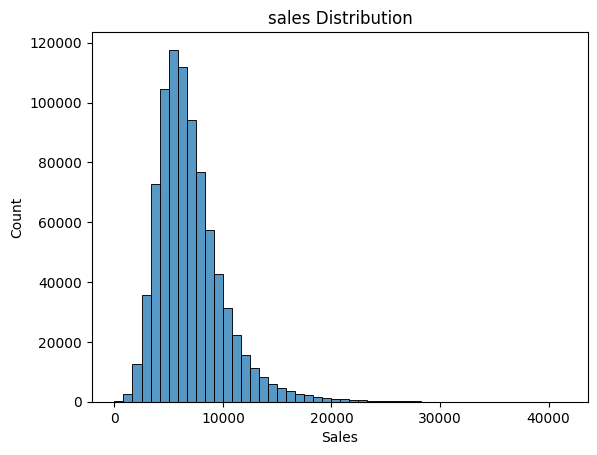

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Sales"], bins = 50)
plt.title("sales Distribution")
plt.show()

### Business Insight
##### Most stores generates moderate daily revenue, while a small number of high performing days contribute disproportionately to total sales

### Recommandation
##### Investigate what happened to extremely high sales days (promotions, holidays, special events) 

### Question 2
#### Do promotions increase sales?

In [19]:
df.groupby("Promo")["Sales"].agg(['mean', 'median', 'count'])

,mean,median,count
Promo,,,
0,5929.407603,5459.0,467496
1,8228.281239,7649.0,376896


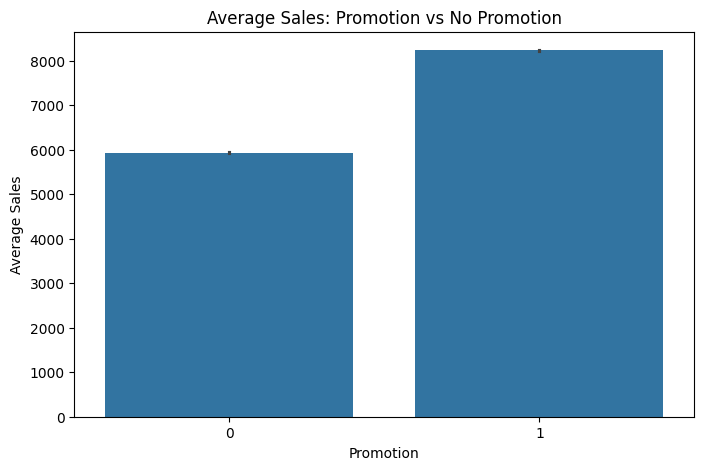

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Promo",
    y="Sales"
)

plt.title("Average Sales: Promotion vs No Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Sales")
plt.show()

8228 - 5929 = 2299, 2299 / 5929 ≈ 38.8% 

### Business Insights
Promotion increase sales by 38.8% than without promotions.
This is a big finding

### Recommandation 
promotions appears highly effective and should be strategically deployed during low demand periods

### Question 3
#### Which store types generate most revenue?

In [20]:
df.groupby("StoreType")["Sales"].mean().sort_values(ascending=False)

StoreType
b    10231.407505
c     6932.512755
a     6925.167661
d     6822.141881
Name: Sales, dtype: float64

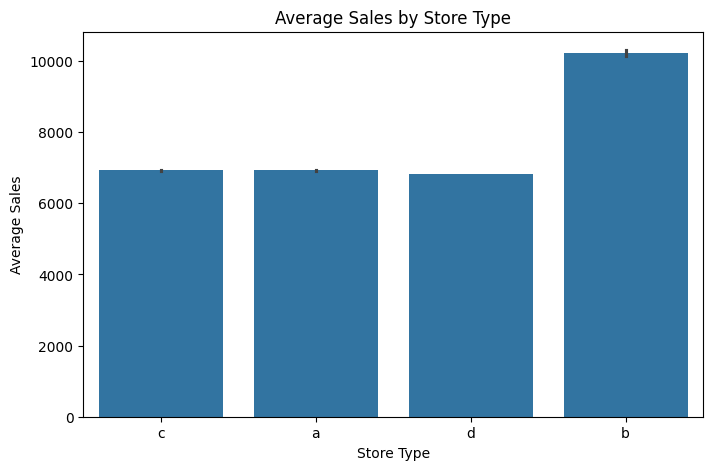

In [58]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="StoreType",
    y="Sales"
)

plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")
plt.show()

### Business Insights
Store Type B significanly outperforms all other store categories
Type B = 48% higher than Type D

### Recommandation
Investigate operational characteristics of Type B stores and evaluate whether similar practices can be applied elsewhere

### Question 4
#### Which assortment type performs best?

In [21]:
df.groupby("Assortment")["Sales"].mean().sort_values(ascending = False)

Assortment
b    8639.346322
c    7300.526339
a    6621.017039
Name: Sales, dtype: float64

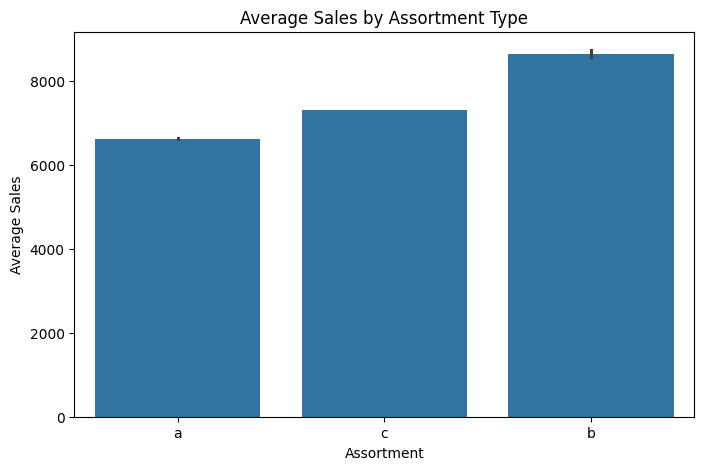

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Assortment",
    y="Sales"
)

plt.title("Average Sales by Assortment Type")
plt.xlabel("Assortment")
plt.ylabel("Average Sales")
plt.show()

### Business Insight
Assortment B generates 30% more sales among all assortment strategies

### Recommendation
Evaluate whether expanding Assortment B to additional stores could increase revenue

# Time vs Sales

In [22]:
df["Date"] = pd.to_datetime(df["Date"])

test_df["Date"] = pd.to_datetime(test_df["Date"])

/var/folders/3g/jhxc4q_x2gz2jrxw2572x8q40000gn/T/ipykernel_74319/1720963115.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date"] = pd.to_datetime(df["Date"])


In [23]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day_name"] = df["Date"].dt.day_name()



test_df["Year"] = test_df["Date"].dt.year
test_df["Month"] = test_df["Date"].dt.month
test_df["Day_name"] = test_df["Date"].dt.day_name()


/var/folders/3g/jhxc4q_x2gz2jrxw2572x8q40000gn/T/ipykernel_74319/544836456.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Year"] = df["Date"].dt.year
/var/folders/3g/jhxc4q_x2gz2jrxw2572x8q40000gn/T/ipykernel_74319/544836456.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Month"] = df["Date"].dt.month
/var/folders/3g/jhxc4q_x2gz2jrxw2572x8q40000gn/T/ipykernel_74319/544836456.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

In [24]:
df.groupby("Year")["Sales"].mean().sort_values(ascending = False)

Year
2015    7088.126648
2014    7025.404201
2013    6814.392025
Name: Sales, dtype: float64

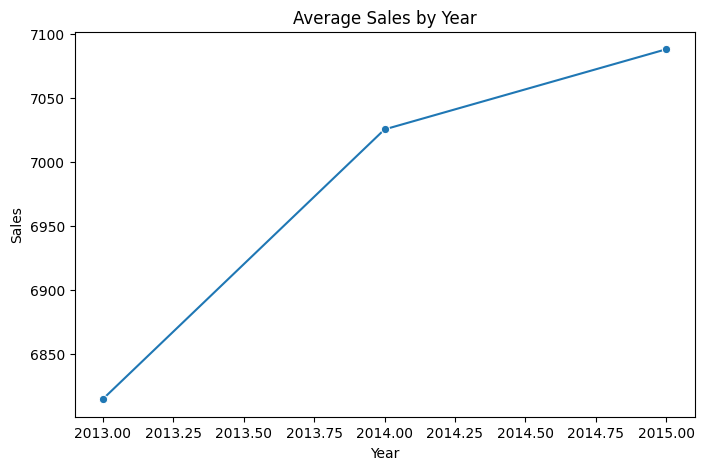

In [60]:
year_sales = df.groupby("Year")["Sales"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=year_sales,
    x="Year",
    y="Sales",
    marker="o"
)

plt.title("Average Sales by Year")
plt.show()

In [25]:
df.groupby("Month")["Sales"].mean().sort_values(ascending = False)

Month
12    8608.956661
11    7188.554250
5     7106.453154
4     7046.228420
6     7000.978190
3     6976.412026
7     6952.682125
8     6648.984654
10    6602.843354
2     6589.165535
1     6563.690444
9     6546.343035
Name: Sales, dtype: float64

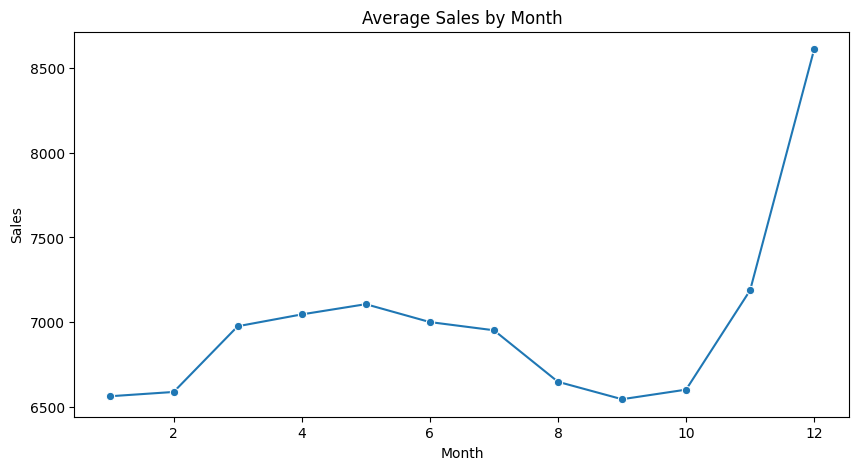

In [61]:
month_sales = df.groupby("Month")["Sales"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=month_sales,
    x="Month",
    y="Sales",
    marker="o"
)

plt.title("Average Sales by Month")
plt.show()

### Month -> Business Insights
dec vs sept = 31.5% higher sales
Possible Explanation :
- Holiday Shopping 
- Chrismas Shopping
- End-year Promotions

### Recommandation

Increase inventory, staffing, and promotional activities during November and December to capitalize to peak demand

In [26]:
df.groupby("Day_name")["Sales"].mean().sort_values(ascending = False)

Day_name
Sunday       8224.723908
Monday       8216.073074
Tuesday      7088.113656
Friday       7072.677012
Thursday     6767.310159
Wednesday    6728.122978
Saturday     5874.840238
Name: Sales, dtype: float64

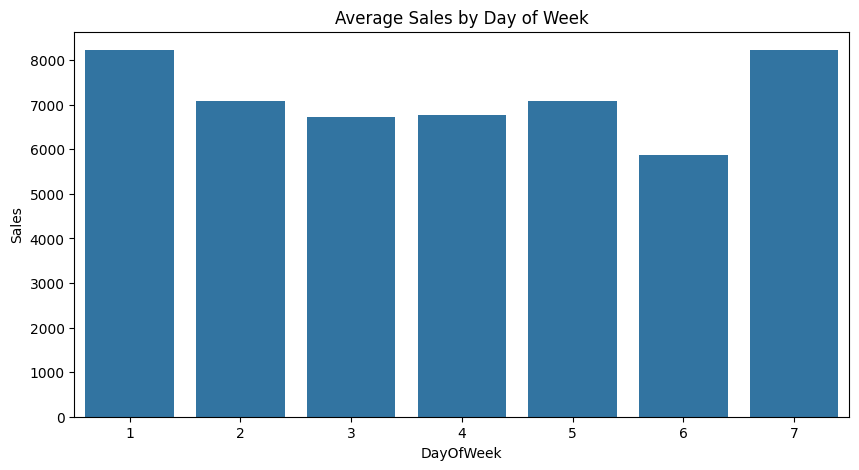

In [62]:
day_sales = df.groupby("DayOfWeek")["Sales"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=day_sales,
    x="DayOfWeek",
    y="Sales"
)

plt.title("Average Sales by Day of Week")
plt.show()

### Day -> Business Insights
Sunday and Monday are strongest sales days, while saturday generates the lowest average revenue

### Recommandation
Investigate why saturday underperforms and consider targeted promotions or staffing adjustments

## What you have discovered so far

### Finding 1
Promotions increase average sales by approximately 39%.

### Finding 2
Store Type B is the highest-performing store category.

### Finding 3
Assortment B produces the highest average revenue.

### Finding 4
December is the strongest sales month.

### Finding 5
Sunday and Monday are the strongest sales days.

### Finding 6
Sales have grown steadily from 2013 to 2015.

In [27]:
df.groupby("StateHoliday")["Sales"].mean()

StateHoliday
0    6701.492117
0    6992.158856
a    8487.471182
b    9887.889655
c    9743.746479
Name: Sales, dtype: float64

In [28]:
df.groupby("SchoolHoliday")["Sales"].mean()

SchoolHoliday
0    6896.782411
1    7200.181650
Name: Sales, dtype: float64

### SchoolHoliday -> Business Insights
School holidays have a positive  but moderate impact in sales

### Recommandation
Consider family oriented promotions during school holidays periods

In [29]:
df.groupby("Promo2")["Sales"].mean() ## long term promotion

Promo2
0    7350.557935
1    6558.386062
Name: Sales, dtype: float64

### Surprising Finding

At first glance: Stores participating in Promo2 generate lower average sales.
This does NOT mean Promo2 is bad.
#### We should immediately ask:
- Are lower-performing stores more likely to receive Promo2?
- Are store types different?
- Are regions different?

"Can we conclude Promo2 reduces sales?"
No. This is observational data. We would need further analysis to determine causality.

Current findings:

Revenue Drivers

✅ Promotions increase sales by ~39%

✅ State holidays significantly increase sales

✅ School holidays slightly increase sales

✅ December is the strongest month

✅ Store Type B is the highest-performing store category

✅ Assortment B produces the highest revenue

✅ Revenue grows from 2013 → 2015

### Store vs Sales

In [30]:
# Top stores
df.groupby("Store")["Sales"].mean().sort_values(ascending = False).head(10)

Store
817     21757.483418
262     20718.515924
1114    20666.562500
251     19123.068036
842     18574.795820
513     18179.089286
562     17969.556263
788     17961.914541
383     17294.716667
756     16574.816431
Name: Sales, dtype: float64

In [31]:
# Bottom stores
df.groupby("Store")["Sales"].mean().sort_values().head(10)

Store
307    2703.736573
543    2790.380282
198    2900.604859
208    2936.290816
841    2972.608974
254    3005.983312
794    3083.812821
219    3133.712452
210    3193.984596
425    3237.659794
Name: Sales, dtype: float64

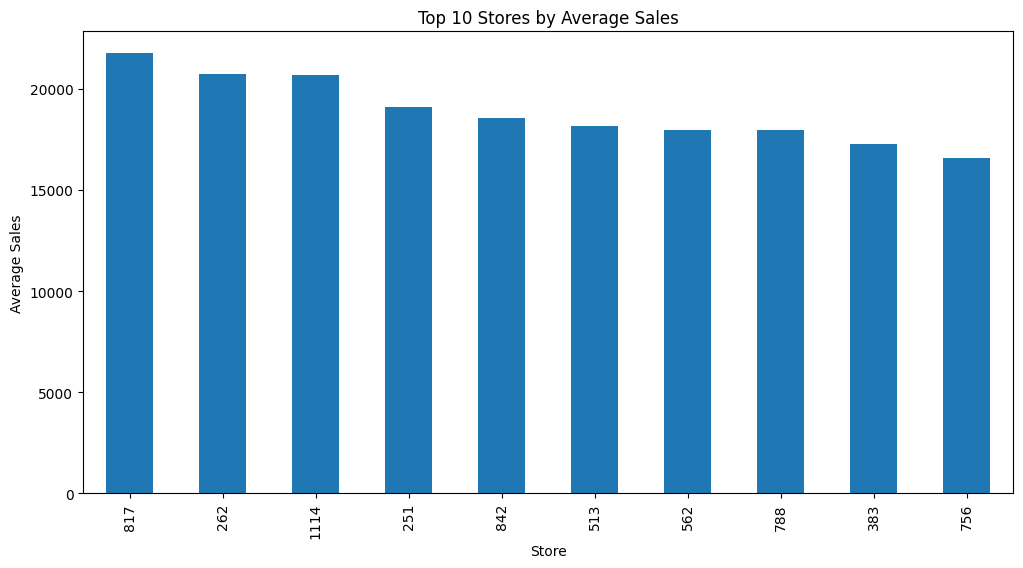

In [64]:
##Top 10 Stores

top_stores = (
    df.groupby("Store")["Sales"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_stores.plot(kind="bar")

plt.title("Top 10 Stores by Average Sales")
plt.ylabel("Average Sales")
plt.show()

In [32]:
y = df["Sales"]
x = df.drop("Sales", axis=1)

In [33]:
x.columns

Index(['Store', 'DayOfWeek', 'Date', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day_name'],
      dtype='object')

## Train_Test split

In [34]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)

(675513, 20)
(168879, 20)


# Modeling

### Feature Engineering

In [35]:
df.dtypes

Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
Year                                  int32
Month                                 int32
Day_name                             object
dtype: object

### One-Hot Encoding

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

x_train = x_train.copy()
x_test = x_test.copy()
x_test_ = test_df.copy()

cat_cols = ["StateHoliday", "StoreType", "Assortment", "Promo",
    "SchoolHoliday", "Promo2"] 
num_cols = ["Store", "DayOfWeek", "Month", "Year"]

preprocessor = ColumnTransformer([

    ("onehot", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

## If any cat_col has mixed values like int and str -> 0, "a", "b", "c"
x_train[cat_cols] = x_train[cat_cols].astype(str)
x_test[cat_cols] = x_test[cat_cols].astype(str)
x_test_[cat_cols] = x_test_[cat_cols].astype(str)


In [37]:
x_train["StateHoliday"]

947192     0
512268     0
1008918    0
521587     0
836684     0
          ..
312959     0
439627     0
159818     0
806510     0
148738     0
Name: StateHoliday, Length: 675513, dtype: object

In [38]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)
x_test_processed_ = preprocessor.transform(x_test_)

## fit_transform → learn categories from training data + convert
## transform → convert test data using same learned categories

## 1. Linear Regression

In [39]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train_processed, y_train)

y_pred_lr = lr.predict(x_test_processed)
y_pred_lr

array([6333.04974157, 8581.59225196, 7157.30805461, ..., 5387.14435403,
       6917.80637879, 6544.29854278], shape=(168879,))

#### Evaluate LR

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE_LR", mae_lr)
print("RMSE_LR", rmse_lr)
print("R2_lr", r2_lr)

Linear Regression
MAE_LR 2019.3053455620575
RMSE_LR 7655528.861736129
R2_lr 0.206167849837258


In [41]:
print(y_test.min(), y_test.max())
print(y_pred_lr.min(), y_pred_lr.max())

0 38037
4106.255255721451 14944.388111307519


#### Linear Regression -> Interpretation
LR served as a baseline model but showed limited predictive power. The model explained only 20.6% of the vairance in sales and tented to predict values near the avg sales range, indicating underfitting.

## 2. Random Forest

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=1
)

rf.fit(x_train_processed, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
y_pred_rf = rf.predict(x_test_processed)
y_pred_rf

array([ 5284.98180952,  9177.25666667,  7298.4       , ...,
        6527.81795238,  8380.52866667, 14710.925     ], shape=(168879,))

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE_RF:", mae_rf)
print("RMSE_RF:", rmse_rf)
print("R2_RF:", r2_rf)

MAE_RF: 740.3416692073306
RMSE_RF: 1128.5863825343872
R2_RF: 0.8679242464305436


## Business Interpretation
### Linear Regression
Failed to capture complex relationships between promotions, store characteristics, holidays, and sales.

### Random Forest
Successfully captured nonlinear patterns and explained approximately 86.8% of sales variability.


## 3. XGBoost

In [45]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb.fit(x_train_processed, y_train)

y_pred_xgb = xgb.predict(x_test_processed)
y_pred_xgb

array([ 5291.8423,  7827.3037,  7275.8794, ...,  6603.5117,  7672.8604,
       13266.595 ], shape=(168879,), dtype=float32)

In [46]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE_XGB:", mae_xgb)
print("RMSE_XGB:", rmse_xgb)
print("R2_XGB:", r2_xgb)

MAE_XGB: 1302.8944091796875
RMSE_XGB: 1812.8556892372874
R2_XGB: 0.6592153310775757


## 4. Gradient Boosting Regressor

In [47]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gbr.fit(x_train_processed, y_train)

y_pred_gbr = gbr.predict(x_test_processed)
y_pred_gbr

array([6210.51862808, 7845.73928139, 6794.19462739, ..., 5970.80881873,
       6861.83023814, 9127.45052829], shape=(168879,))

In [48]:
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("MAE_GBR:", mae_gbr)
print("RMSE_GBR:", rmse_gbr)
print("R2_GBR:", r2_gbr)

MAE_GBR: 1819.8569809061808
RMSE_GBR: 2469.7658369001465
R2_GBR: 0.36749342624200576


## 5. Decision Tree Regressor

In [49]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt.fit(x_train_processed, y_train)

y_pred_dt = dt.predict(x_test_processed)
y_pred_dt

array([6261.08946609, 8933.94460523, 5131.57307863, ..., 5878.6356745 ,
       6695.84500515, 6124.04283361], shape=(168879,))

In [50]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE_DT:", mae_dt)
print("RMSE_DT:", rmse_dt)
print("R2_DT:", r2_dt)

MAE_DT: 1773.8745206468923
RMSE_DT: 2437.186215959203
R2_DT: 0.38407063196636126


In [51]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_gbr,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_gbr,
        rmse_xgb
    ],
    "R2": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gbr,
        r2_xgb
    ]
})

results.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
2,Random Forest,740.341669,1.128586e+03,0.867924
4,XGBoost,1302.894409,1.812856e+03,0.659215
1,Decision Tree,1773.874521,2.437186e+03,0.384071
3,Gradient Boosting,1819.856981,2.469766e+03,0.367493
0,Linear Regression,2019.305346,7.655529e+06,0.206168


### Insights
Random Forest achieved the best performance with Rˆ2 of 0.867924, indicating that it captured nonlinear relationships between promotions, store characteristics, holidays, and sales better than the other models


## Feature Importance Random forest

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

##Get feature names after OneHotEncoding
 
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['onehot__StateHoliday_0', 'onehot__StateHoliday_a',
       'onehot__StateHoliday_b', 'onehot__StateHoliday_c',
       'onehot__StoreType_a', 'onehot__StoreType_b',
       'onehot__StoreType_c', 'onehot__StoreType_d',
       'onehot__Assortment_a', 'onehot__Assortment_b',
       'onehot__Assortment_c', 'onehot__Promo_0', 'onehot__Promo_1',
       'onehot__SchoolHoliday_0', 'onehot__SchoolHoliday_1',
       'onehot__Promo2_0', 'onehot__Promo2_1', 'num__Store',
       'num__DayOfWeek', 'num__Month', 'num__Year'], dtype=object)

In [53]:
##Create feature imp dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by = "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
17,num__Store,0.577118
18,num__DayOfWeek,0.074164
12,onehot__Promo_1,0.069481
11,onehot__Promo_0,0.069462
19,num__Month,0.063280
5,onehot__StoreType_b,0.025049
20,num__Year,0.023573
4,onehot__StoreType_a,0.016069
10,onehot__Assortment_c,0.013580
7,onehot__StoreType_d,0.012319


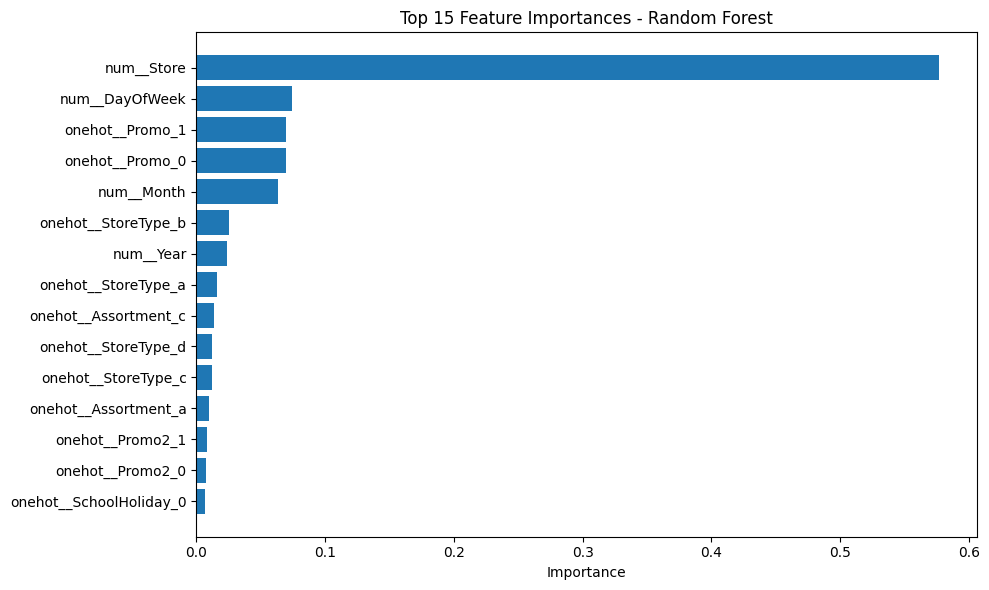

In [54]:
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - Random Forest")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The Store identifier emerged as the most important feature, indicating substantial differences in sales performance across stores. Since Store is an identifier rather than a business attribute, feature importance should be interpreted with caution.

#### Top Drivers of Sales
1. Store (~58%) ⭐
2. DayOfWeek (~7%)
3. Promo (~7%)
4. Month (~6%)
5. StoreType B
6. Year
7. StoreType A
8. Assortment C

This means the identity of the store itself explains most of the variation in sales

DayOfWeek matters, Imp = 7%, consistent with the EDA. Sunday and Monday had highest average sales.

Promotion matters 7%, Promo sales ≈ 8228, No Promo sales ≈ 5929


Because Store Dominates feature importance, Store-specific characterritics are the strongest frivers of sales performance. This suggest that location, customer base, and operational factors unique to each store have a significant impact on revenue generation.



# Project Conclusion

### You now have: Business Insights

✅ Promotions increase sales by ~39%
✅ State holidays increase sales
✅ December is the strongest month
✅ Store Type B performs best
✅ Assortment B performs best
✅ Sales increased from 2013 → 2015


### Top sales drivers:

- Store
- DayOfWeek
- Promotion
- Month
- StoreType
- Year

In [55]:
test_predictions = rf.predict(x_test_processed_)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "Sales": test_predictions
})

submission.head()


,Id,Sales
0,1,4190.620000
1,2,7688.821333
2,3,10444.925000
3,4,8552.500000
4,5,8021.507333


In [56]:
submission.to_csv(
    "submission.csv",
    index=False
)

The target variable (Sales) is hidden in the real test set of Kaggle datasets. Therefore evaluation metrics such as MAE, RMSE, and R² can only be computed on a validation split of the training data. The test set is used solely for generating predictions.